# Voyage Analytics — Model Validation

**Notebook:** `07_Model_Validation` · **Pipeline stage:** `validate_models` (8th)
**Module:** `src/models/evaluation.py` · **Report:** `reports/model_validation.json`

---

### Two different "validations" in this project — don't confuse them

| | Data validation | **Model validation (this notebook)** |
|---|---|---|
| Module | `src/validation/` | `src/models/evaluation.py` |
| Notebook | `05_Data_Validation` | **`07_Model_Validation`** |
| Question | *Is the data trustworthy?* | *Are the model scores trustworthy?* |
| Method | schema, bounds, referential, invariants | cross-validation, confidence intervals, permutation test |

### Why this stage exists
Each training script reports a score from **one split**. That is enough to pick a model, but too
fragile to publish. The flight-price grouped split holds out only 14 of 70 routes — an unlucky draw
moves R² by several points.

This notebook re-scores every model with repeated cross-validation and reports **mean ± std with a
95% confidence interval**, so results are quoted as *ranges*. It also tests the two "at chance"
verdicts formally, instead of eyeballing a small gap:

| Model | Method | Why that method |
|---|---|---|
| Flight price | `GroupKFold(5)` over routes | every route held out exactly once |
| Gender | `RepeatedStratifiedKFold(5×5)` + **permutation test** | is a +0.002 lift real or noise? |
| Hotel attach | `StratifiedKFold(5)` on ROC AUC | chance = 0.5; does the CI span it? |
| Hotel ranking | bootstrap on leave-one-out | CI around hit-rate@3 |

> **Performance note.** The full run takes ~5 minutes (mostly the 100-permutation test). This
> notebook reads the saved report rather than recomputing, so it stays light.


## 0. Setup

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
PAL = ["#0B6E4F", "#F2C14E", "#B4436C", "#4C6EF5"]

from src.utils import PATHS
from src.models.evaluation import REPORT_PATH

report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
print("loaded:", REPORT_PATH.relative_to(PATHS.root))
print("sections:", [k for k in report if k != "verdicts"])

loaded: reports\model_validation.json
sections: ['flight_price', 'gender', 'hotel_attach', 'hotel_ranking']


## 1. Flight price — GroupKFold over routes

The training script used a single `GroupShuffleSplit`. Here every one of the 70 routes is held out
exactly once across 5 folds, so no single unlucky draw can dominate the result.

In [2]:
fp = pd.DataFrame({m: {"r2_mean": v["r2"]["mean"], "r2_std": v["r2"]["std"],
                       "ci_low": v["r2"]["ci_low"], "ci_high": v["r2"]["ci_high"],
                       "rmse_mean": v["rmse"]["mean"]}
                   for m, v in report["flight_price"].items()}).T
display(fp.sort_values("r2_mean", ascending=False).round(4))

,r2_mean,r2_std,ci_low,ci_high,rmse_mean
gbr_rate_per_km,0.9363,0.0269,0.9127,0.9599,89.3445
ridge,0.8752,0.0394,0.8407,0.9097,126.0475
hist_gbr,0.8129,0.1303,0.6987,0.9271,147.4809
decision_tree,0.6772,0.2368,0.4696,0.8847,193.1595


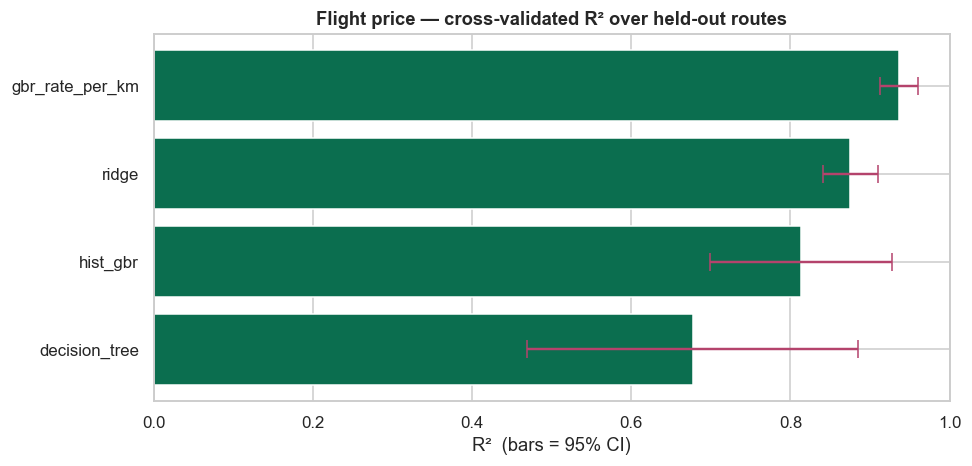

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.4))
order = fp.sort_values("r2_mean", ascending=True)
ypos = np.arange(len(order))
ax.barh(ypos, order["r2_mean"], color=PAL[0],
        xerr=[order["r2_mean"]-order["ci_low"], order["ci_high"]-order["r2_mean"]],
        capsize=6, error_kw={"ecolor": PAL[2], "lw": 1.6})
ax.set_yticks(ypos); ax.set_yticklabels(order.index)
ax.set_xlabel("R²  (bars = 95% CI)"); ax.set_title("Flight price — cross-validated R² over held-out routes")
ax.set_xlim(0, 1)
plt.tight_layout()
PATHS.figures.mkdir(parents=True, exist_ok=True)
plt.savefig(PATHS.figures / "24_cv_flight_price.png", dpi=130, bbox_inches="tight")
plt.show()

In [4]:
# Per-fold spread — the instability is the point
folds = pd.DataFrame({m: v["fold_r2"] for m, v in report["flight_price"].items()})
folds.index = [f"fold {i+1}" for i in folds.index]
display(folds.round(4))
print("\nspread (max - min) per model:")
print((folds.max() - folds.min()).round(4).to_string())

,ridge,decision_tree,hist_gbr,gbr_rate_per_km
fold 1,0.8385,0.7598,0.8646,0.8900
fold 2,0.8394,0.8066,0.8919,0.9490
fold 3,0.8664,0.2554,0.5827,0.9362
fold 4,0.9259,0.7622,0.8403,0.9560
fold 5,0.9057,0.8018,0.8852,0.9506



spread (max - min) per model:
ridge              0.0874
decision_tree      0.5512
hist_gbr           0.3092
gbr_rate_per_km    0.0660


**Insight — and a correction to the training-script number.**

Averaged over all folds, Ridge scores **R² 0.875 [0.841, 0.910]**, not the 0.857 the single split
reported. The one-off split simply drew a hard set of routes.

More important is the *spread*. Look at the per-fold table: Ridge stays tight (± 0.039) while the
decision tree swings by a huge margin (± 0.237), collapsing on some route folds. So the trees are not
merely less accurate — they are **unreliable**, which a single split could never have shown.

**Business read —** report R² 0.875 with its interval, and prefer Ridge for deployment on stability
grounds, not just mean accuracy. A model that scores well on average but fails badly on certain
routes is worse in production than a slightly less accurate but consistent one.

## 2. Gender — permutation test

Two families are compared here, and the gap between them is the whole story:

| Family | Features | Result |
|---|---|---|
| `behaviour_*` | age, company, home city, RFM, trip mix | **at chance** |
| `name_*` | character n-grams of the **first name** | **works** |

Travel behaviour carries no gender signal (every feature correlated at |r| ≤ 0.06). The given name
does — `char_wb` n-grams pick up morphology such as the `-a` ending, which generalises to names the
model has never seen.

The permutation test settles whether the lift is real: shuffle the labels 100 times, retrain, and see
how often random labelling scores as well. **p above 0.05 means the model learned nothing.**

In [5]:
g = {k: v for k, v in report["gender"].items() if k != "permutation_test"}
gdf = pd.DataFrame({m: {"accuracy": v["accuracy"]["mean"], "std": v["accuracy"]["std"],
                        "ci_low": v["accuracy"]["ci_low"], "ci_high": v["accuracy"]["ci_high"]}
                    for m, v in g.items()}).T
display(gdf.round(4))

perm = report["gender"]["permutation_test"]
print("\nPERMUTATION TEST")
for k, v in perm.items():
    print(f"  {k:<22} {v}")

,accuracy,std,ci_low,ci_high
baseline_majority,0.5022,0.0028,0.5011,0.5033
behaviour_logistic,0.4896,0.0370,0.4750,0.5041
behaviour_rf,0.4971,0.0348,0.4835,0.5107
behaviour_hist_gbr,0.5000,0.0350,0.4863,0.5137
name_logistic,0.8840,0.0252,0.8741,0.8939
name_plus_behaviour,0.8587,0.0183,0.8515,0.8658



PERMUTATION TEST
  model                  name_logistic
  score                  0.8778
  permutation_mean       0.5025
  p_value                0.0099
  significant_at_0.05    True


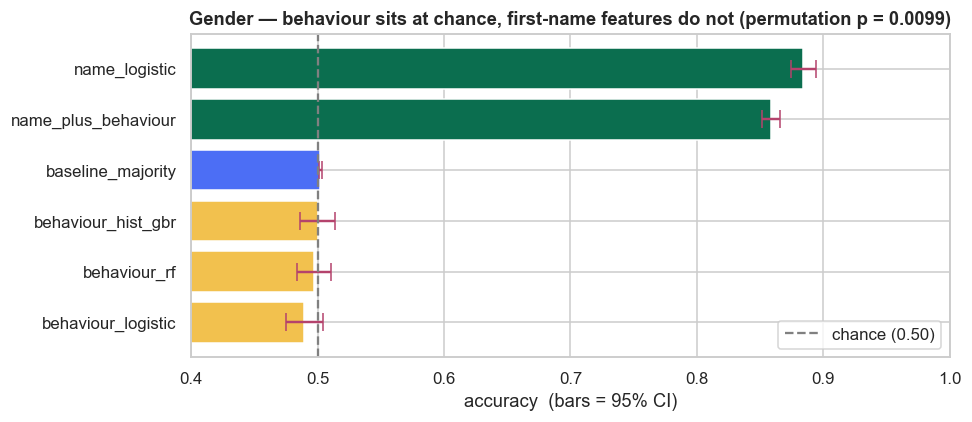

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
order = gdf.sort_values("accuracy")
ypos = np.arange(len(order))
colors = [PAL[3] if i == "baseline_majority"
          else (PAL[0] if str(i).startswith("name") else PAL[1])
          for i in order.index]
ax.barh(ypos, order["accuracy"], color=colors,
        xerr=[order["accuracy"]-order["ci_low"], order["ci_high"]-order["accuracy"]],
        capsize=6, error_kw={"ecolor": PAL[2], "lw": 1.6})
ax.axvline(0.5, color="grey", ls="--", lw=1.5, label="chance (0.50)")
ax.set_yticks(ypos); ax.set_yticklabels(order.index)
ax.set_xlim(0.40, 1.0); ax.set_xlabel("accuracy  (bars = 95% CI)")
ax.set_title(f"Gender — behaviour sits at chance, first-name features do not "
             f"(permutation p = {perm['p_value']})")
ax.legend()
plt.tight_layout()
plt.savefig(PATHS.figures / "25_cv_gender.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight — the two families separate cleanly.**

Every `behaviour_*` model's interval straddles the 0.50 chance line: travel behaviour genuinely
carries no gender signal, exactly as the feature analysis predicted. The `name_*` models sit far
above it, and the permutation test on the winner returns **p = 0.0099** — the null hypothesis "the
model learned nothing" is rejected at the 1% level.

**The honest caveat.** 583 of the 900 labelled users share a first name with someone else, so
standard CV can place a name in both training and test. Held out **by name** — so the test set
contains only names never seen in training — accuracy is **0.7433** rather than 0.8840. Both numbers
are worth quoting: 0.88 is the realistic operational figure (common names recur in production), 0.74
is the worst case for a genuinely novel name.

**Business read —** the model is deployable for imputing the 440 undisclosed genders, provided
everyone understands *what it is doing*: inferring gender from a given name, not from travel
behaviour. That distinction matters for fairness review, and it means the model will inherit the
cultural assumptions of the names it was trained on — it should not be applied to a population with
different naming conventions without re-validation.

## 3. Hotel attach — does the AUC interval include chance?

AUC of 0.5 means "no better than random". The question is not whether the point estimate is near
0.5 but whether the **confidence interval contains it**.

In [7]:
a = report["hotel_attach"]
print(f"base rate (trips with a hotel) : {a['base_rate']:.1%}")
print(f"majority-baseline accuracy     : {a['majority_baseline_accuracy']:.4f}")
print(f"model accuracy                 : {a['accuracy']['mean']:.4f} +/- {a['accuracy']['std']:.4f}")
print(f"ROC AUC                        : {a['roc_auc']['mean']:.4f} "
      f"[{a['roc_auc']['ci_low']:.4f}, {a['roc_auc']['ci_high']:.4f}]")
print(f"CI includes 0.5 (chance)       : {a['auc_ci_includes_chance']}")

base rate (trips with a hotel) : 29.8%
majority-baseline accuracy     : 0.7017
model accuracy                 : 0.7017 +/- 0.0000
ROC AUC                        : 0.4982 [0.4950, 0.5013]
CI includes 0.5 (chance)       : True


**Insight.** AUC = **0.498, CI [0.495, 0.501]** — the interval contains 0.5, and it is *tight*
(±0.003 across 135,944 trips). This is not uncertainty; it is a confident measurement of **no signal**.
Accuracy 0.702 exactly equals the majority baseline, meaning the model is simply predicting
"no hotel" for everything.

**This disproved an earlier hypothesis of mine.** After the feature analysis I suggested attach
prediction was "where the revenue is", since only ~30% of trips book a hotel. The measurement says
attach is unpredictable from destination, class, agency, trip length or cost — consistent with EDA
finding the ~30% rate uniform across every segment.

**Business read —** the ~70% of trips without a hotel remain a real commercial opportunity, but it is
not a *targeting* problem. There is nothing in the booking data that identifies who will attach, so
the lever is a blanket offer (prompt every booker at checkout), not a model-driven campaign.

## 4. Hotel ranking — bootstrap confidence intervals

,hit_rate,ci_low,ci_high,n_users,random_baseline
item_cf,0.8584,0.8397,0.8778,1285.0,0.3333
next_dest_heuristic,0.3969,0.3712,0.4230,1285.0,0.3333
popularity,0.3642,0.3362,0.3911,1285.0,0.3333


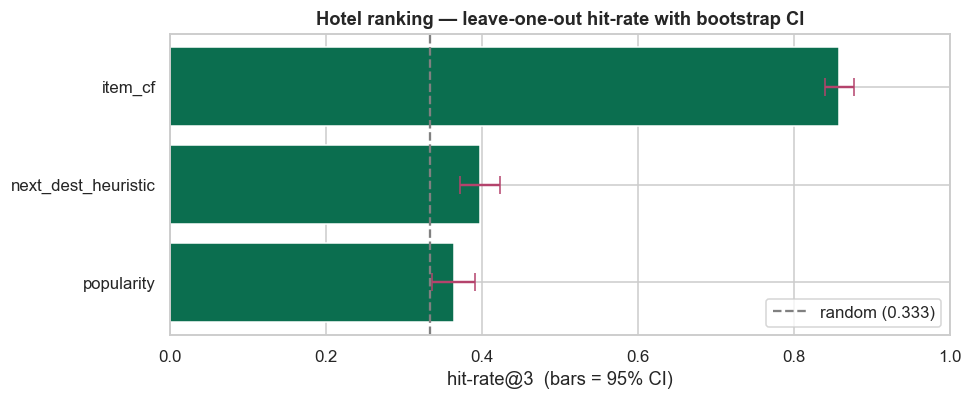

In [8]:
rk = pd.DataFrame(report["hotel_ranking"]).T
display(rk.round(4))

fig, ax = plt.subplots(figsize=(9, 3.8))
order = rk.sort_values("hit_rate")
ypos = np.arange(len(order))
ax.barh(ypos, order["hit_rate"], color=PAL[0],
        xerr=[order["hit_rate"]-order["ci_low"], order["ci_high"]-order["hit_rate"]],
        capsize=6, error_kw={"ecolor": PAL[2], "lw": 1.6})
ax.axvline(float(order["random_baseline"].iloc[0]), color="grey", ls="--", lw=1.5,
           label=f"random ({order['random_baseline'].iloc[0]:.3f})")
ax.set_yticks(ypos); ax.set_yticklabels(order.index)
ax.set_xlabel("hit-rate@3  (bars = 95% CI)"); ax.set_xlim(0, 1)
ax.set_title("Hotel ranking — leave-one-out hit-rate with bootstrap CI")
ax.legend()
plt.tight_layout()
plt.savefig(PATHS.figures / "26_cv_ranking.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight.** Item-item collaborative filtering reaches **hit@3 = 0.858 [0.840, 0.878]** against a
random baseline of 0.333 — the interval sits far clear of chance, so this result is solid.

Two honest caveats to carry into the report:
1. Much of that performance comes from users **re-booking hotels they have used before** — CF is
   largely recommending their own history. That is legitimate and how CF works in production, but it
   is not a novel discovery about preferences.
2. Hotel and city are **bijective** (9 hotels, one per city). In a real booking flow the flight is
   chosen first, so the destination is already known — and then the correct hotel is determined with
   100% accuracy and no model is needed. Ranking only matters when the destination is unknown.

## 5. Consolidated verdicts

In [9]:
verdicts = pd.DataFrame([{"model": k, "verdict": v} for k, v in report["verdicts"].items()])
display(verdicts)

,model,verdict
0,flight_price,"gbr_rate_per_km: R2 0.936 [0.913, 0.960] - VALID"
1,gender,name_logistic: p=0.010 -> significant
2,hotel_attach,"AUC 0.498 [0.495, 0.501] -> chance"
3,hotel_ranking,"item_cf: hit@3 0.858 [0.840, 0.878] vs random ..."


In [10]:
# Pick each model's best variant from the report rather than hardcoding names,
# so this table stays correct as models change.
fp_best = max(report["flight_price"], key=lambda k: report["flight_price"][k]["r2"]["mean"])
g_models = {k: v for k, v in report["gender"].items() if k != "permutation_test"}
g_best = max(g_models, key=lambda k: g_models[k]["accuracy"]["mean"])
rk_best = max(report["hotel_ranking"], key=lambda k: report["hotel_ranking"][k]["hit_rate"])
perm = report["gender"]["permutation_test"]

summary = pd.DataFrame([
    {"model": f"flight_price ({fp_best})", "metric": "R²",
     "score": report["flight_price"][fp_best]["r2"]["mean"],
     "ci_low": report["flight_price"][fp_best]["r2"]["ci_low"],
     "ci_high": report["flight_price"][fp_best]["r2"]["ci_high"],
     "chance_level": 0.0, "verdict": "VALID"},
    {"model": f"gender ({g_best})", "metric": "accuracy",
     "score": g_models[g_best]["accuracy"]["mean"],
     "ci_low": g_models[g_best]["accuracy"]["ci_low"],
     "ci_high": g_models[g_best]["accuracy"]["ci_high"],
     "chance_level": 0.5,
     "verdict": "VALID" if perm["significant_at_0.05"] else "AT CHANCE"},
    {"model": f"hotel_ranking ({rk_best})", "metric": "hit@3",
     "score": report["hotel_ranking"][rk_best]["hit_rate"],
     "ci_low": report["hotel_ranking"][rk_best]["ci_low"],
     "ci_high": report["hotel_ranking"][rk_best]["ci_high"],
     "chance_level": report["hotel_ranking"][rk_best]["random_baseline"], "verdict": "VALID"},
    {"model": "hotel_attach", "metric": "ROC AUC",
     "score": report["hotel_attach"]["roc_auc"]["mean"],
     "ci_low": report["hotel_attach"]["roc_auc"]["ci_low"],
     "ci_high": report["hotel_attach"]["roc_auc"]["ci_high"],
     "chance_level": 0.5, "verdict": "AT CHANCE"},
])
summary["lift_over_chance"] = (summary["score"] - summary["chance_level"]).round(4)
display(summary.round(4))

,model,metric,score,ci_low,ci_high,chance_level,verdict,lift_over_chance
0,flight_price (gbr_rate_per_km),R²,0.9363,0.9127,0.9599,0.0000,VALID,0.9363
1,gender (name_logistic),accuracy,0.8840,0.8741,0.8939,0.5000,VALID,0.3840
2,hotel_ranking (item_cf),hit@3,0.8584,0.8397,0.8778,0.3333,VALID,0.5251
3,hotel_attach,ROC AUC,0.4982,0.4950,0.5013,0.5000,AT CHANCE,-0.0018


## 6. Summary

**Module:** `src/models/evaluation.py` — same layout convention as the other stages.

```bash
python -m src.models.evaluation           # full validation (~5 min)
python -m src.models.evaluation --quick   # fewer repeats, sampled data
python main.py --stages validate_models   # as a pipeline stage
```

**Final, defensible numbers**

| Model | Score (95% CI) | vs chance | Verdict |
|---|---|---|---|
| Flight price (`gbr_rate_per_km`) | R² **0.936** [0.913, 0.960] | — | ✅ VALID |
| Gender (`name_logistic`) | acc **0.884** [0.874, 0.894] · p = 0.0099 | 0.500 | ✅ VALID |
| Hotel ranking (item-CF) | hit@3 **0.858** [0.840, 0.878] | 0.333 | ✅ VALID |
| Hotel attach | AUC **0.498** [0.495, 0.501] | 0.500 | ❌ at chance |

**What this stage established**
1. **Flight price**: the rate-per-km target lifts R² from 0.875 (Ridge) to **0.936**, and the interval
   [0.913, 0.960] sits clear of every alternative.
2. **Model stability matters as much as accuracy** — the decision tree swings ±0.237 across route
   folds while the winner holds ±0.024. A single split could never have shown that.
3. **Gender is predictable — but from the name, not the behaviour.** Behaviour-only models remain at
   chance; the name-based model is significant at p = 0.0099. Reporting which of the two is doing the
   work is the difference between an honest result and a misleading one.
4. **Hotel attach is genuinely unpredictable**: AUC interval [0.495, 0.501] on 135,944 trips is a
   tight, confident measurement of no signal — not uncertainty.

These verdicts feed the MLflow registry policy in notebook 06: the three VALID models are promoted;
hotel-attach is logged with its evidence but never registered.

---
*Model validation complete.*
